In [1]:
# ================================================================
# PPC: Space-averaged, Time-resolved
# Statistic: mean_i y_{i,t}
# One-step-ahead
# 5 MODELS:
#   IID / BYM shared / BYM weekly / BYM+cov / BYM weekly+cov
# ================================================================

import numpy as np
import pyreadr
import pickle
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import geopandas as gpd
from scipy.spatial.distance import pdist, squareform
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components

np.random.seed(1)

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------

BASE_DIR = Path(r"D:\77\Research\temp\snow")
PERIOD = 52
N_REP = 1000

no_nbs = np.array([
    57,170,236,269,343,685,946,947,989,
    1037,1084,1090,1109,1118,1127,1176,1203
]) - 1

# ------------------------------------------------------------
# LOAD + 2PC FILTER (same as spatial version)
# ------------------------------------------------------------

snow = pyreadr.read_r(BASE_DIR / "snow_cleaned_full.Rda")
snow = list(snow.values())[0]

coords_full = snow.iloc[:, :2].to_numpy()
y_full = snow.iloc[:, 2:].to_numpy()

coords_tmp = np.delete(coords_full, no_nbs, axis=0)
y_tmp = np.delete(y_full, no_nbs, axis=0)

gdf = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy(coords_tmp[:,0], coords_tmp[:,1]),
    crs="EPSG:4326"
).to_crs("+proj=aeqd +lat_0=90 +lon_0=-100")

xy = np.vstack([gdf.geometry.x, gdf.geometry.y]).T / 1e6
D = squareform(pdist(xy))
W = (D <= 0.22).astype(int)
np.fill_diagonal(W, 0)
W = csr_matrix(W)

n_comp, labels = connected_components(W, directed=False)
sizes = np.bincount(labels)
order = np.argsort(sizes)[::-1]

keep = np.sort(np.concatenate([
    np.where(labels == order[0])[0],
    np.where(labels == order[1])[0]
]))

coords = coords_tmp[keep]
y = y_tmp[keep]

S, T = y.shape
print("Using S =", S)

# ------------------------------------------------------------
# OBSERVED TEMPORAL STATISTIC
# ------------------------------------------------------------

T_obs = y[:,1:].mean(axis=0)  # (T-1,)

# ------------------------------------------------------------
# TIME COVARIATES (same as spatial version)
# ------------------------------------------------------------

t_raw = np.arange(1, T+1)
t_trend = (t_raw - t_raw.mean()) / t_raw.std()

cov4 = np.column_stack([
    np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD),
    t_trend
])

cov8 = np.column_stack([
    np.ones(T), np.ones(T),
    np.cos(2*np.pi*t_raw/PERIOD), np.cos(2*np.pi*t_raw/PERIOD),
    np.sin(2*np.pi*t_raw/PERIOD), np.sin(2*np.pi*t_raw/PERIOD),
    t_trend, t_trend
])

week = (t_raw - 1) % 52

# ------------------------------------------------------------
# SPATIAL COVARIATES (2pc-consistent)
# ------------------------------------------------------------

lat = coords[:,1]
lat = (lat - lat.mean()) / lat.std()

elev_df = pd.read_csv(BASE_DIR / "curr_elev.csv")
elev_all = elev_df.iloc[:,3].to_numpy()
elev = elev_all[keep]
elev = (elev - elev.mean()) / elev.std()

snow_temp = pyreadr.read_r(BASE_DIR / "snow_temp_full.Rda")
snow_temp = list(snow_temp.values())[0].reset_index(drop=True)
temp_all = snow_temp.drop(index=no_nbs).iloc[:,2:].to_numpy()
temp = temp_all[keep]
temp = (temp - temp.mean()) / temp.std()

# ------------------------------------------------------------
# LOAD POSTERIORS
# ------------------------------------------------------------

iid01 = np.load(BASE_DIR / "ind01.npz")["all_theta"]
iid10 = np.load(BASE_DIR / "ind10.npz")["all_theta"]

bym01 = np.load(BASE_DIR / "bym01.npz")["all_theta"]
bym10 = np.load(BASE_DIR / "bym10.npz")["all_theta"]

bym01_cov = np.load(BASE_DIR / "bym01_cov.npz")["all_theta"]
bym10_cov = np.load(BASE_DIR / "bym10_cov.npz")["all_theta"]

with open(BASE_DIR / "bym01_weekly.pkl","rb") as f:
    weekly01 = pickle.load(f)
with open(BASE_DIR / "bym10_weekly.pkl","rb") as f:
    weekly10 = pickle.load(f)

eta01_week = weekly01["all_eta"]
tau01_week = weekly01["all_tau"]
eta10_week = weekly10["all_eta"]
tau10_week = weekly10["all_tau"]

with open(BASE_DIR / "bym01_cov_weekly.pkl","rb") as f:
    wf01 = pickle.load(f)
with open(BASE_DIR / "bym10_cov_weekly.pkl","rb") as f:
    wf10 = pickle.load(f)

eta01_wf = wf01["all_eta"]
tau01_wf = wf01["all_tau"]
eta10_wf = wf10["all_eta"]
tau10_wf = wf10["all_tau"]

M = iid01.shape[1]

# ------------------------------------------------------------
# SIGMOID
# ------------------------------------------------------------

def sigmoid(z):
    return 1/(1+np.exp(-z))

# ------------------------------------------------------------
# GENERIC SIMULATOR
# ------------------------------------------------------------

def simulate(get_eta):

    draws = np.random.choice(M, N_REP, replace=False)
    T_pred = np.zeros((N_REP, T-1))

    for j, m in enumerate(tqdm(draws)):

        y_rep = np.zeros((S,T), dtype=int)
        y_rep[:,0] = y[:,0]

        for t in range(1,T):

            eta01, eta10 = get_eta(m,t)

            p01 = sigmoid(eta01)
            p10 = sigmoid(eta10)

            prev = y_rep[:,t-1]
            prob = np.where(prev==0, p01, 1-p10)

            y_rep[:,t] = np.random.binomial(1, prob)

            T_pred[j,t-1] = y_rep[:,t].mean()

    return np.mean(T_pred >= T_obs[None,:], axis=0)

# ------------------------------------------------------------
# ETA DEFINITIONS
# ------------------------------------------------------------

def eta_iid(m,t):
    e1 = sum(cov4[t,k]*iid01[k*S:(k+1)*S,m] for k in range(4))
    e2 = sum(cov4[t,k]*iid10[k*S:(k+1)*S,m] for k in range(4))
    return e1,e2

def eta_bym(m,t):
    e1 = sum(cov8[t,k]*bym01[k*S:(k+1)*S,m] for k in range(8))
    e2 = sum(cov8[t,k]*bym10[k*S:(k+1)*S,m] for k in range(8))
    return e1,e2

def eta_week(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_week[k*S:(k+1)*S,m]
        beta2 = eta10_week[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_week[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_week[k*52+w,m]
    return e1,e2

def eta_cov(m,t):
    e1,e2 = eta_bym(m,t)
    gamma1 = bym01_cov[8*S:8*S+3,m]
    gamma2 = bym10_cov[8*S:8*S+3,m]
    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])
    return e1+fac@gamma1, e2+fac@gamma2

def eta_week_cov(m,t):
    w = week[t]
    e1 = np.zeros(S)
    e2 = np.zeros(S)
    for k in range(8):
        beta1 = eta01_wf[k*S:(k+1)*S,m]
        beta2 = eta10_wf[k*S:(k+1)*S,m]
        e1 += cov8[t,k]*beta1*tau01_wf[k*52+w,m]
        e2 += cov8[t,k]*beta2*tau10_wf[k*52+w,m]
    gamma1 = eta01_wf[8*S:8*S+3,m]
    gamma2 = eta10_wf[8*S:8*S+3,m]
    fac = np.column_stack([
        t_trend[t]*lat,
        t_trend[t]*elev,
        t_trend[t]*temp[:,t]
    ])
    return e1+fac@gamma1, e2+fac@gamma2

# ------------------------------------------------------------
# RUN
# ------------------------------------------------------------

print("\nIID")
p_iid = simulate(eta_iid)

print("\nBYM shared")
p_bym = simulate(eta_bym)

print("\nBYM weekly")
p_week = simulate(eta_week)

print("\nBYM + cov")
p_cov = simulate(eta_cov)

print("\nBYM weekly + cov")
p_week_cov = simulate(eta_week_cov)

Using S = 1557

IID


100%|██████████| 1000/1000 [13:28<00:00,  1.24it/s]



BYM shared


100%|██████████| 1000/1000 [22:41<00:00,  1.36s/it]



BYM weekly


100%|██████████| 1000/1000 [25:45<00:00,  1.55s/it]



BYM + cov


100%|██████████| 1000/1000 [27:48<00:00,  1.67s/it]



BYM weekly + cov


100%|██████████| 1000/1000 [25:00<00:00,  1.50s/it]


In [2]:

def summarize(name, pvals):
    print("\n", name)
    print("Mean:", pvals.mean())
    print("SD:", pvals.std())
    print("Pr(p<0.05):", np.mean(pvals < 0.05))
    print("Pr(p>0.95):", np.mean(pvals > 0.95))

summarize("IID", p_iid)
summarize("BYM shared", p_bym)
summarize("BYM weekly", p_week)
summarize("BYM+cov", p_cov)
summarize("BYM weekly+cov", p_week_cov)


 IID
Mean: 0.5085142434332224
SD: 0.47228644468284375
Pr(p<0.05): 0.4099149093599704
Pr(p>0.95): 0.4339622641509434

 BYM shared
Mean: 0.505172401035886
SD: 0.47249716555949045
Pr(p<0.05): 0.412504624491306
Pr(p>0.95): 0.43026267110617833

 BYM weekly
Mean: 0.4928142804291528
SD: 0.4675655644646736
Pr(p<0.05): 0.4232334443211247
Pr(p>0.95): 0.39696633370329265

 BYM+cov
Mean: 0.5157247502774694
SD: 0.46885068550986786
Pr(p<0.05): 0.3951165371809101
Pr(p>0.95): 0.4295227524972253

 BYM weekly+cov
Mean: 0.4867798742138365
SD: 0.46772007686390266
Pr(p<0.05): 0.42582315945246024
Pr(p>0.95): 0.39178690344062156


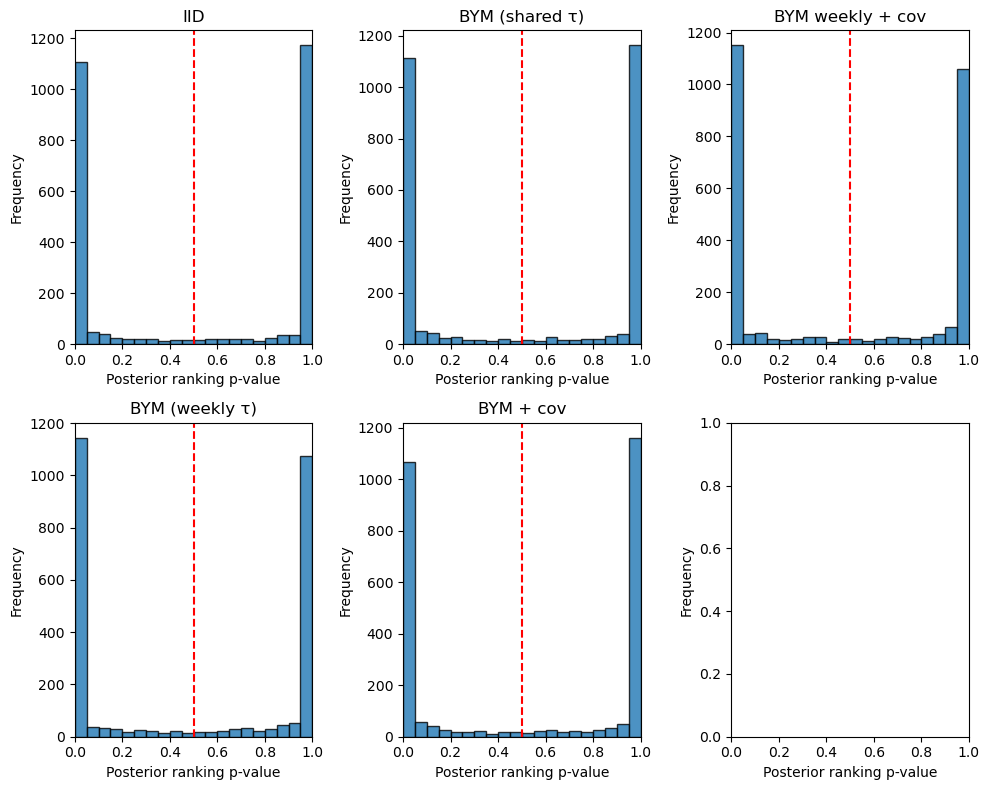

In [3]:
import matplotlib.pyplot as plt
import numpy as np

bins = np.linspace(0, 1, 21)

fig, axes = plt.subplots(2, 3, figsize=(10,8))

# ---------------------------
# IID
# ---------------------------
axes[0,0].hist(p_iid, bins=bins, edgecolor="black", alpha=0.8)
axes[0,0].axvline(0.5, color="red", linestyle="--")
axes[0,0].set_title("IID")
axes[0,0].set_xlim(0,1)

# ---------------------------
# BYM shared
# ---------------------------
axes[0,1].hist(p_bym, bins=bins, edgecolor="black", alpha=0.8)
axes[0,1].axvline(0.5, color="red", linestyle="--")
axes[0,1].set_title("BYM (shared τ)")
axes[0,1].set_xlim(0,1)

# ---------------------------
# BYM weekly
# ---------------------------
axes[1,0].hist(p_week, bins=bins, edgecolor="black", alpha=0.8)
axes[1,0].axvline(0.5, color="red", linestyle="--")
axes[1,0].set_title("BYM (weekly τ)")
axes[1,0].set_xlim(0,1)

# ---------------------------
# BYM + cov
# ---------------------------
axes[1,1].hist(p_cov, bins=bins, edgecolor="black", alpha=0.8)
axes[1,1].axvline(0.5, color="red", linestyle="--")
axes[1,1].set_title("BYM + cov")
axes[1,1].set_xlim(0,1)


# ---------------------------
# BYM Weekly + cov
# ---------------------------
axes[0,2].hist(p_week_cov, bins=bins, edgecolor="black", alpha=0.8)
axes[0,2].axvline(0.5, color="red", linestyle="--")
axes[0,2].set_title("BYM weekly + cov")
axes[0,2].set_xlim(0,1)

for ax in axes.flat:
    ax.set_xlabel("Posterior ranking p-value")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

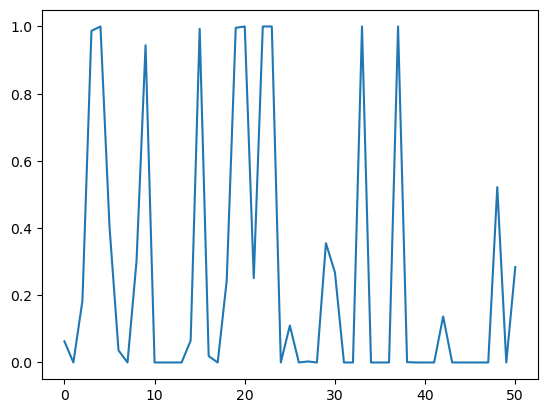

In [10]:
plt.plot(p_iid[:51])